In [14]:
EXP_NAME="28APR"
raw_dataset="28APR_unbiased_raw"
n_samples = 2000
seed = 4

In [15]:
import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
  from google.colab import userdata
  from google.colab import drive
  drive.mount('/content/drive')
  PROJECT_ROOT = userdata.get('PROJECT_ROOT')
else:
  PROJECT_ROOT = '../..'

In [16]:
import numpy as np
import pandas as pd
from scipy.stats import skewnorm, gamma, beta, truncnorm
from scipy.special import expit
from scipy.optimize import bisect
import matplotlib.pyplot as plt
import seaborn as sns
from data_utils import simulate_selection_bias, class_balanced_sampling, scale_dataset, apply_additive_unfair_bias, plot_cont_feature, plot_cat_feature

In [17]:
raw_dataset = pd.read_csv(f'../../data/{raw_dataset}.csv')

___

# Introducing bias

## Additive bias

In [36]:
mild_bias_df = apply_additive_unfair_bias(raw_dataset, s_target=0, bias_prob=0.5, s1_max_shift=2, b1_mean_shift=12.0, b1_std_shift=3.0, proc_risk_penalty=4, seed=seed)

# Sampling

## Unbiased, balanced sampling

In [37]:
mild_bias_sampled_df = class_balanced_sampling(mild_bias_df, n_samples, seed)

print(f"Target size: {n_samples} | Actual size: {len(mild_bias_sampled_df)}")
print(f"Prevalence in sample: {mild_bias_sampled_df['outcome_Y'].mean():.2%}")

Target size: 2000 | Actual size: 1987
Prevalence in sample: 49.07%


## Selection bias

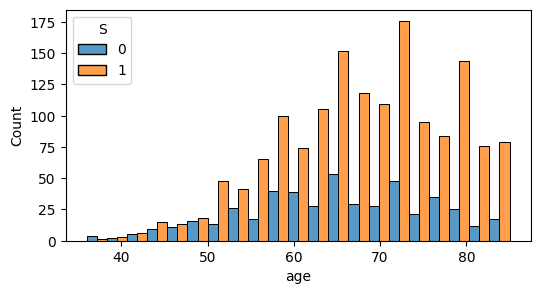

In [38]:
# Run the selection
mild_bias_select_df = simulate_selection_bias(mild_bias_df, n_target=n_samples)

fig, ax = plt.subplots(figsize=(6, 3))
sns.histplot(data=mild_bias_select_df, x='age', multiple='dodge', ax=ax, hue='S', stat='count')
plt.show()

# Data processing

In [39]:
norm_variables = ['age', "biomarker_1_obs", "biomarker_3"]
skewed_variables = ["biomarker_2"]

# Mild bias dataset
mild_bias_sampled_df_proc = scale_dataset(mild_bias_sampled_df, norm_variables, skewed_variables)

mild_bias_sampled_df_proc.to_csv(f'{PROJECT_ROOT}/data/{EXP_NAME}_mild_bias.csv', index=False)

# Mild bias + Selection bias dataset
mild_bias_select_df_proc = scale_dataset(mild_bias_select_df, norm_variables, skewed_variables)

mild_bias_select_df_proc.to_csv(f'{PROJECT_ROOT}/data/{EXP_NAME}_mild_bias_select.csv', index=False)

# Visualisation

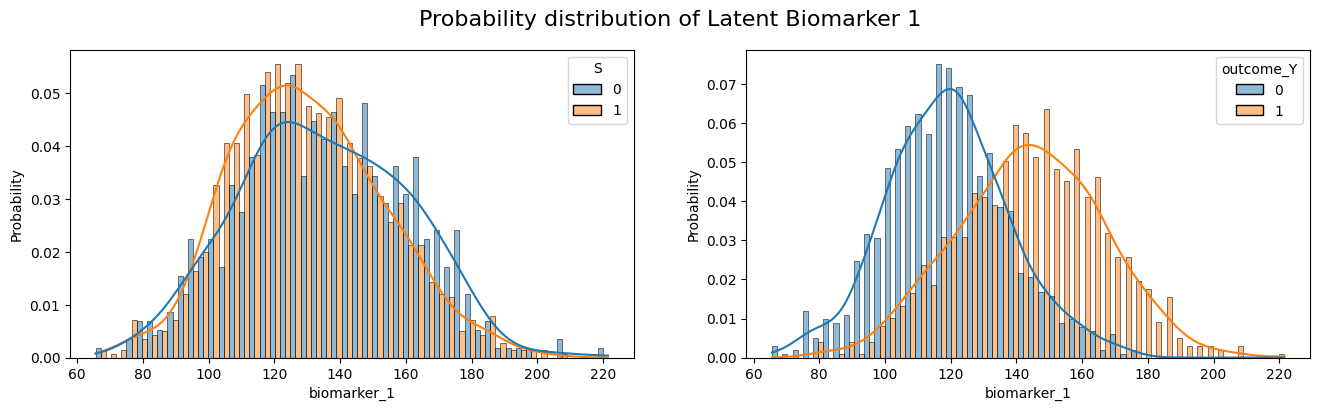

In [40]:
fig = plot_cont_feature(mild_bias_sampled_df, "biomarker_1", "Latent Biomarker 1")

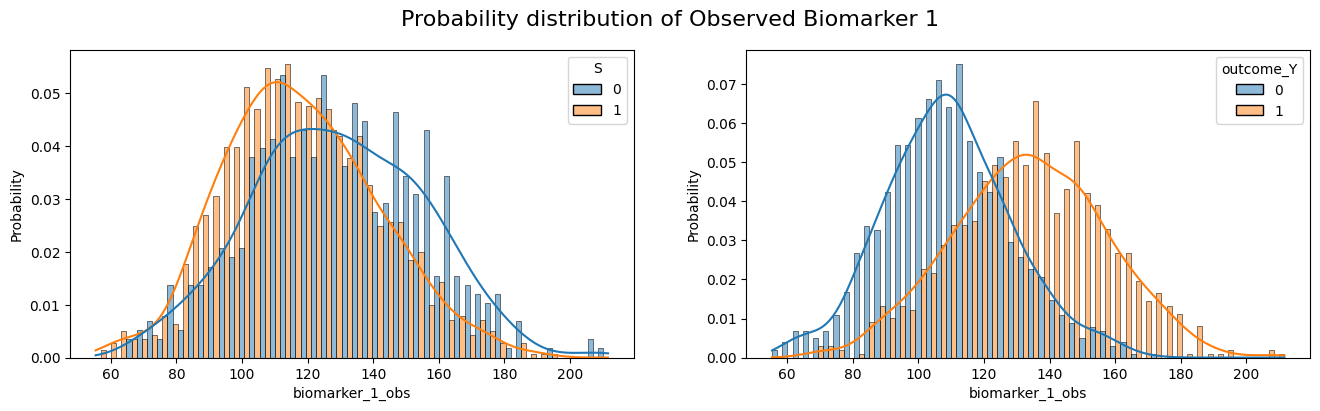

In [41]:
fig = plot_cont_feature(mild_bias_sampled_df, "biomarker_1_obs", "Observed Biomarker 1")

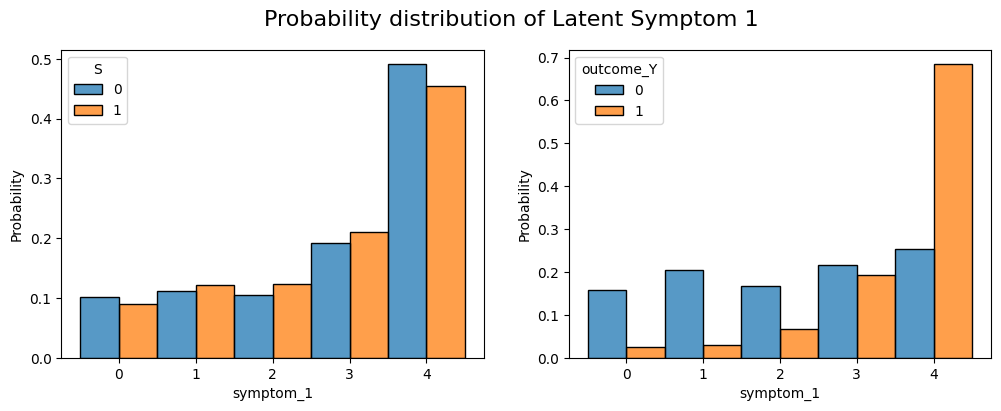

In [42]:
fig = plot_cat_feature(mild_bias_sampled_df, "symptom_1", "Latent Symptom 1")

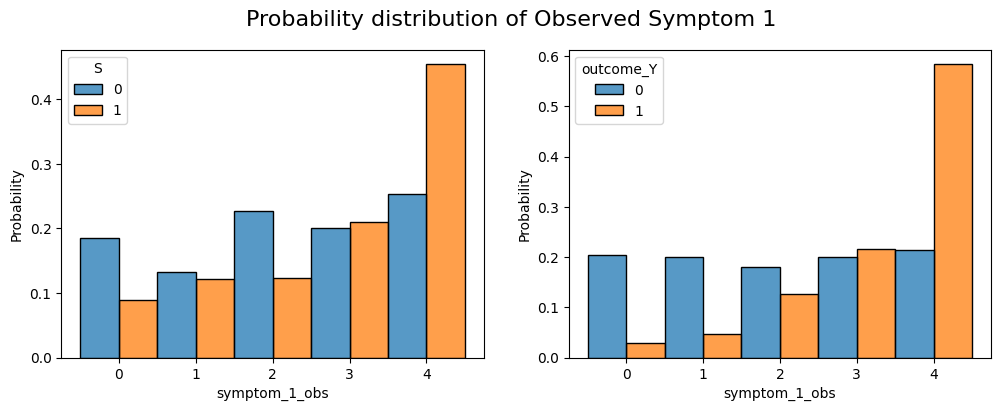

In [43]:
fig = plot_cat_feature(mild_bias_sampled_df, "symptom_1_obs", "Observed Symptom 1")

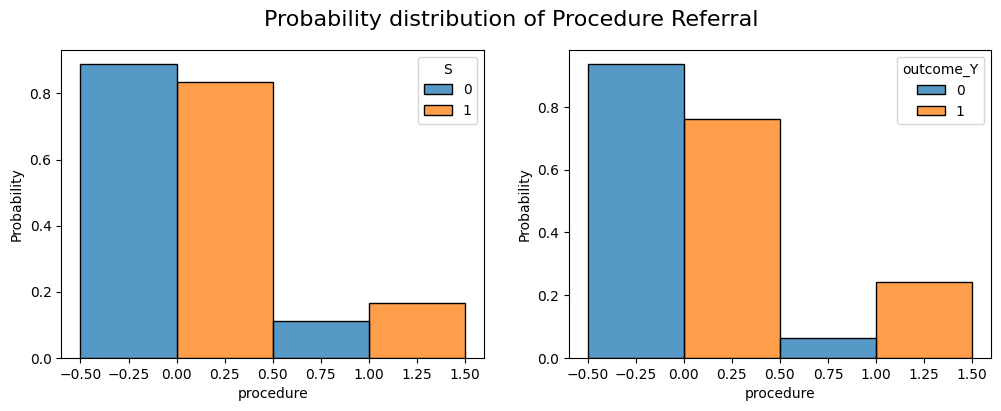

In [44]:
fig = plot_cat_feature(mild_bias_sampled_df, "procedure", "Procedure Referral")